# Recherche d'information dans la littérature scientifique

**MOD 7.2 (Introduction à la sciences des données)**, BE séances 4, 5, 6

**Enseignants :** Julien Velcin (CM, BE), Erwan Versmée (BE)

Le projet qu'on vous demande de réaliser est un **moteur de recherche** qui, étant donnée une publication, retourne les articles qui en sont le plus proche sémantiquement.
Pour simplifier le problème, pour une **requête donnée** (*query*), càd un article, on vous fournit 5 articles cités par celui-ci (les exemples positifs) et environ 25 articles choisis aléatoirement dans la base (les exemples négatifs).

La tâche consiste alors à construire un algorithme capable de **retourner les 5 citations et écarter les autres**.

Notez, qu'en plus du titre, d'**autres informations** susceptibles d'être utiles vous sont fournies : court résumé textuel, auteur(s) de l’article, année de publication, références bibliographiques, quels autres articles le citent.

**Exemple :**

Titre de l'article ciblé (notre requête, pour simplifier) : *"Bearish-Bullish Sentiment Analysis on Financial Microblogs"*

Quelques exemples positifs :

> "SemEval-2015 Task 11: Sentiment Analysis of Figurative Language in Twitter"
>
> "Text mining of news-headlines for FOREX market prediction: A Multi-layer Dimension Reduction Algorithm with semantics and sentiment"

Quelques exemples négatifs :

> "Analysis and Design of Average Current Mode Control Using a Describing-Function-Based Equivalent Circuit Model"
>
> "MVOR: A Multi-view RGB-D Operating Room Dataset for 2D and 3D Human Pose Estimation"


Votre moteur se basera sur un système *S* qui doit mesurer à quel point un article candidat *c* répond bien à la requête *q* à l'aide d'un **score d'appariement** S(q,c) : plus ce score est élevé, mieux l'article correspond à la requête.

Si *q* est la requête et *C* l'ensemble des candidats (environ 25 pour chaque requête), composés d'exemples positifs *C+* et négatifs *C-*, alors il faut que *S* retourne préférentiellement les exemples de *C+*, donc leur attribue un score important.


## Setup and Import Libraries

Ici se trouvent un certain nombre de librairies dont vous pourriez avoir besoin. Néanmoins, rien ne vous oblige à tout utiliser et vous pouvez ajouter vos propres librairies. Il est cependant important qu'il soit possible pour une tierce personne d'installer le nécessaire pour exécuter votre code.

In [1]:
pip install -U sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print("Please install with: pip install sentence-transformers scikit-learn networkx")

np.random.seed(42)

Required libraries imported successfully!


Le code qui suit peut être utile pour réaliser des affichages à partir de la matrice Documents x Termes, libre à vous de l'utiliser.

In [3]:
from scipy.sparse import find, csr_matrix
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import norm
from IPython.core.display import HTML

# des options permettent de limiter (ou non) le nombre de lignes/colonnes affichées
# par exemple :
# pd.set_option('display.max_rows', None)

# cette fonction permet d'afficher une "jolie" représentation du vecteur v
# ARGS :
#   v : le vecteur à afficher (par ex. une ligne de la matrice X)
#   features : le vocabulaire
#   top_n : le nombre de mots maximum à afficher
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})   

# fonction qui permet d'afficher plusieurs tables pandas côte à côte (c'est cadeau)
def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "&emsp;"
        #output += "\xa0\xa0\xa0"
    display(HTML(output))

## 1. Chargement et prise en main des données

La première étape consiste bien entendu à charger les données en mémoire et aller voir comment celles-ci sont structurées. On vous fournit 3 fichiers pour commencer :

- *corpus.jsonl* : le corpus lui-même, composé de plus de 25k articles scientifiques
- *queries.jsonl* : l'ensemble des documents qui constituent les requêtes qui seront adressées à notre moteur. Ces documents proviennent du corpus, mais il peut s'agir de documents qui ne sont que cités ou citent d'autres documents et pour lesquels on n'a que très peu d'information.
- *valid.tsv* : l'ensemble des données nécessaires pour entraîner et/ou tester votre moteur

Voilà un extrait du fichier *corpus.jsonl* :

![corpus](./corpus.jpg "Title")

Voilà un extrait du fichier *queries.jsonl* :

![corpus](./queries.jpg "Title")

Voilà un extrait du fichier *valid.tsv* :

![corpus](./test.jpg "Title")

Par la suite, on vous fournira à priori un 4ème fichier (*test_final.tsv*) qui contiendra des nouvelles données sur lesquelles vous pourrez réaliser  des prédictions. Les identifiants des candidats sont toujours tirés de votre corpus d'articles.

Nous vous conseillons d'employer la libraire *json* pour charger les données des deux premiers fichiers et utiliser des dictionnaires afin de pouvoir accéder aux articles via leurs identifiants. Pour rappel, un fichier *jsonl* n'est rien d'autre qu'un fichier dans lequel chaque ligne est composé d'un objet json bien formaté.

In [4]:
import json
from typing import Dict


def load_corpus(file_path: str) -> Dict[str, Dict]:
    """
    Load corpus data from a JSONL file.
    Returns:
        dict mapping document_id -> document_data
    """
    corpus = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            doc = json.loads(line)
            corpus[doc["_id"]] = doc
    return corpus


def load_queries(file_path: str) -> Dict[str, Dict]:
    """
    Load query data from a JSONL file.
    Returns:
        dict mapping query_id -> query_data
    """
    queries = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            query = json.loads(line)
            queries[query["_id"]] = query
    return queries


def load_qrels(file_path: str) -> Dict[str, Dict[str, int]]:
    """
    Load relevance judgments from TSV file.
    Format expected: query_id \t candidate_id \t relevance
    """
    qrels = {}
    with open(file_path, "r", encoding="utf-8") as f:
        next(f)  # skip header line
        
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 3:
                continue   # ignore malformed lines
            
            qid, cid, rel = parts
            rel = int(rel)

            if qid not in qrels:
                qrels[qid] = {}

            qrels[qid][cid] = rel

    return qrels

In [5]:
# Load the dataset
print("Loading dataset...")
corpus = load_corpus('corpus.jsonl')
queries = load_queries('queries.jsonl')
qrels_valid = load_qrels('valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


## 2. Exploration des données et premier encodage

A présent, on vous propose de réaliser un certain nombre d'opérations pour mieux connaître vos données. Tout d'abord, il s'agit de calculer des statistiques simples telles que :

- Taille du corpus et du nombre de requêtes
- Nombre de paires requête / document
- Proportions de documents pertinents (non pertinents) par requête

On affiche un exemple de requête (vous pouvez vous limiter au titre de l'article), accompagnée d'exemples de candidats positifs et de candidats négatifs.

In [6]:
# TODO
print("===== Statistiques de base =====")

# Taille du corpus et du nombre de requêtes
print(f"Nombre de documents dans le corpus   : {len(corpus)}")
print(f"Nombre de requêtes dans queries.jsonl : {len(queries)}")
print(f"Nombre de requêtes dans valid.tsv     : {len(qrels_valid)}")

# Nombre total de paires (query, document) dans valid.tsv
total_pairs = sum(len(cands) for cands in qrels_valid.values())
print(f"Nombre total de paires requête/document dans valid.tsv : {total_pairs}")

# Proportions de documents pertinents par requête
proportions = []
nb_pos_total = 0
nb_neg_total = 0

for qid, cand_dict in qrels_valid.items():
    total_cands = len(cand_dict)
    nb_pos = sum(1 for rel in cand_dict.values() if rel == 1)
    nb_neg = total_cands - nb_pos
    nb_pos_total += nb_pos
    nb_neg_total += nb_neg
    proportions.append(nb_pos / total_cands)

print(f"Nombre total de documents pertinents   : {nb_pos_total}")
print(f"Nombre total de documents non pertinents : {nb_neg_total}")
print(f"Proportion moyenne de pertinents par requête : {sum(proportions)/len(proportions):.3f}")
print(f"Proportion min / max de pertinents par requête : {min(proportions):.3f} / {max(proportions):.3f}")


===== Statistiques de base =====
Nombre de documents dans le corpus   : 25657
Nombre de requêtes dans queries.jsonl : 1000
Nombre de requêtes dans valid.tsv     : 700
Nombre total de paires requête/document dans valid.tsv : 20950
Nombre total de documents pertinents   : 3450
Nombre total de documents non pertinents : 17500
Proportion moyenne de pertinents par requête : 0.165
Proportion min / max de pertinents par requête : 0.074 / 0.167


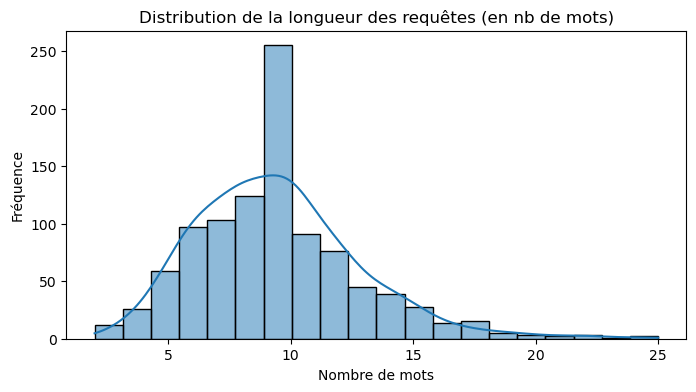

In [7]:
import seaborn as sns
query_lengths = [len(q["text"].split()) for q in queries.values()]

plt.figure(figsize=(8,4))
sns.histplot(query_lengths, bins=20, kde=True)
plt.title("Distribution de la longueur des requêtes (en nb de mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()


In [8]:
print("===== Exemple : une requête avec texte et candidats =====")

# 1) Prendre la première requête présente dans valid.tsv
example_qid = next(iter(qrels_valid.keys()))
print(f"ID de la requête sélectionnée : {example_qid}\n")

# 2) Récupérer le texte de la requête dans queries.jsonl
query_info = queries.get(example_qid)

if query_info is None:
    print("La requête n'existe pas dans queries.jsonl.")
else:
    full_text = query_info.get("text", "[Texte indisponible]")

    # afficher seulement les 12 premiers mots
    short_text = " ".join(full_text.split()[:12]) + "..."
    
    print("--- Aperçu du texte de la requête (12 mots) ---")
    print(short_text)
    print()

    # 3) Séparer candidats positifs et négatifs
    candidates = qrels_valid[example_qid]
    pos_ids = [cid for cid, rel in candidates.items() if rel == 1]
    neg_ids = [cid for cid, rel in candidates.items() if rel == 0]

    print(f"Nombre de candidats positifs : {len(pos_ids)}")
    print(f"Nombre de candidats négatifs : {len(neg_ids)}\n")

    # 4) Afficher candidats POSITIFS avec leur titre
    print("=== Candidats POSITIFS ===")
    for cid in pos_ids[:5]:
        doc = corpus.get(cid, {})
        title = doc.get("title", "[Titre inexistant dans le corpus]")
        print(f"- {cid} : {title}")

    # 5) Afficher candidats NEGATIFS avec leur titre
    print("\n=== Candidats NÉGATIFS ===")
    for cid in neg_ids[:5]:
        doc = corpus.get(cid, {})
        title = doc.get("title", "[Titre inexistant dans le corpus]")
        print(f"- {cid} : {title}")


===== Exemple : une requête avec texte et candidats =====
ID de la requête sélectionnée : 40c6b953b5c04b3df4164cd487c4bc00cf0e487d

--- Aperçu du texte de la requête (12 mots) ---
A Microfluidically Reconfigurable Dual-Band Slot Antenna With a Frequency Coverage Ratio of...

Nombre de candidats positifs : 4
Nombre de candidats négatifs : 25

=== Candidats POSITIFS ===
- d59814a5014f220c1bd43fef6393b1250ecdc58b : A Coplanar Reconfigurable Folded Slot Antenna Without Bias Network for WLAN Applications
- 89c1c6c952e1e962677026269c094b8c0a966ee0 : A Low-Profile Third-Order Bandpass Frequency Selective Surface
- 462881e12a6708ddc520fa4d58c99ba73b18a6ab : Continuous Electrowetting of Non-toxic Liquid Metal for RF Applications
- ef348f8538ae7ce39004a5ce961c7ff747dfba01 : An electromechanical interpretation of electrowetting

=== Candidats NÉGATIFS ===
- 58ab158785a0899210369f76025c1e33c19299f5 : Integration of Modular Process Units Into Process Control Systems
- 8a5444e350e59f69ddf37121d9ede8

**Première approche “classique” avec *CountVectorizer***

Ensuite, utilisez la librairie *scikit-learn* pour réaliser un **premier encodage des données** sous forme de matrice Documents * Termes.
Il suffit pour cela d'utiliser la classe *CountVectorizer* puis d'utiliser les fonction *fit* et *transform* pour (respectivement) construire le vocabulaire et la matrice elle-même.
Pour simplifier et accélérer les calculs, vous pouvez commencer en ne considérant que le titre des articles, mais rien ne vous empêche par la suite d'utiliser également le champ résumé.

Pour le moment, contentez-vous d'utiliser les paramètres par défaut, mais vous pourrez ensuite appliquer de **nombreux prétraitements** tels que la suppression des mots-outils ou la réduction de la taille du vocabulaire. Nous verrons ça dans la section suivante.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
doc_ids = list(corpus.keys())
titles = [corpus[doc_id].get("title", "") for doc_id in doc_ids]
vectorizer = CountVectorizer()
# fit et transform 
X = vectorizer.fit_transform(titles)
print("Taille de la matrice : ", X.shape)
print("Nombre de documents :", X.shape[0])
print("Mots distincts dans le vocabulaire :", X.shape[1])
vocab = vectorizer.get_feature_names_out()
print("Quelques mots du vocabulaire :", vocab[:20])

Taille de la matrice :  (25657, 20075)
Nombre de documents : 25657
Mots distincts dans le vocabulaire : 20075
Quelques mots du vocabulaire : ['00' '000' '00058' '001' '0016' '002' '003' '0031' '004' '01' '018' '02'
 '0212' '025' '03' '048' '05' '06' '08' '0v']


En utilisant la fonction fournie *print_feats*, on affiche les informations contenues dans quelques vecteurs de la base de données.

In [10]:
from scipy.sparse import find
import pandas as pd

# Fonction print_feats
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})

# Récupérer les mots du vocabulaire
features = vectorizer.get_feature_names_out()

# Choisir quelques documents à afficher 
indices = [0, 10, 100]

for idx in indices:
    print(f"\n===== Document {idx} =====")
    print("Titre:", corpus[doc_ids[idx]].get("title", "[Titre indisponible]"))
    
    v = X[idx]  # vecteur du document
    df = print_feats(v, features, top_n=10)
    print(df)



===== Document 0 =====
Titre: A hybrid of genetic algorithm and particle swarm optimization for recurrent network design
           word  value
0     algorithm      1
1           and      1
2        design      1
3           for      1
4       genetic      1
5        hybrid      1
6       network      1
7            of      1
8  optimization      1
9      particle      1

===== Document 10 =====
Titre: Automatic Machine Translation Evaluation: A Qualitative Approach
          word  value
0     approach      1
1    automatic      1
2   evaluation      1
3      machine      1
4  qualitative      1
5  translation      1

===== Document 100 =====
Titre: Detection of exudates in fundus photographs using convolutional neural networks
            word  value
0  convolutional      1
1      detection      1
2       exudates      1
3         fundus      1
4             in      1
5       networks      1
6         neural      1
7             of      1
8    photographs      1
9          using     

On affiche la distribution des mots les plus fréquemment employés dans le corpus. Pour cela, il suffit de faire la somme des occurrences par colonne, puis d'appeler la fonction d'affichage précédente. Ensuite, vous pouvez utiliser la librairie *matplotlib* pour afficher un histogramme qui permet d'avoir une représentation visuelle de cette distribution.

===== Mots les plus fréquents du corpus =====
         word  value
0          of   8911
1         and   8551
2         for   8090
3          in   5103
4         the   4887
5        with   2647
6          on   2558
7       based   2538
8       using   2483
9          to   2261
10   learning   1902
11         an   1633
12       data   1406
13   networks   1282
14   analysis   1254
15  detection   1168
16     system   1044
17     neural   1015
18       from   1014
19       deep    861


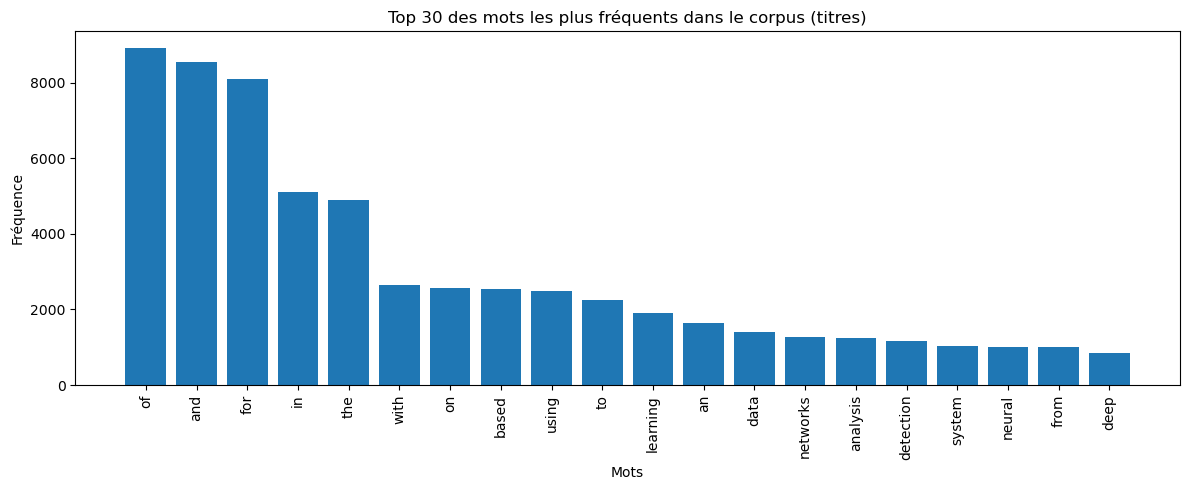

In [11]:
from scipy.sparse import find
import pandas as pd
import matplotlib.pyplot as plt

# Fonction print_feats (fournie)
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})

#  On récupére les features
features = vectorizer.get_feature_names_out()

#  On calcule la distribution globale des mots
word_counts = X.sum(axis=0)        # matrice 1 × vocab_size
word_counts = word_counts.A1       # conversion en array numpy

#  Utilisation de print_feats pour afficher les mots les plus fréquents du corpus
print("===== Mots les plus fréquents du corpus =====")
df_global = print_feats(word_counts, features, top_n=20)
print(df_global)

import matplotlib.pyplot as plt

# On récupère les 30 mots les plus fréquents
df_top = df_global  # résultat de print_feats(word_counts, features)
df_top = df_top.sort_values(by="value", ascending=False).head(30)

plt.figure(figsize=(12, 5))
plt.bar(df_top["word"], df_top["value"])
plt.xticks(rotation=90)
plt.title("Top 30 des mots les plus fréquents dans le corpus (titres)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()



## 3. Comparaison de documents et premier moteur de recherche

Une manière classique de comparer des vecteurs creux (ce qui est le cas pour la matrice Documents x Termes) est d'utiliser la mesure du cosinus. Celle-ci calcule une **similarité entre deux textes** basée sur les mots en commun.

En utilisant la fonction *cosine_similarity* de la *librairie sklearn*, testez cette mesure sur différentes paires de texte. Vous pouvez également travailler avec les résumés des articles. N'hésitez pas à afficher les documents pour observer les mots qu'ils ont en commun.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

print("\n===== Similarité requête / candidats (sur les TITRES) =====")

# 1) Prendre une requête dans valid.tsv
example_qid = next(iter(qrels_valid.keys()))
candidates = qrels_valid[example_qid]

# 2) Récupérer son "titre" dans queries.jsonl 
query_info = queries.get(example_qid)
query_title = query_info.get("text", "") if query_info is not None else ""

short_q = " ".join(query_title.split()[:12]) + "..."
print("ID requête :", example_qid)
print("Titre (queries.jsonl) :", short_q)

# 3) Encoder la requête avec le même vectorizer
q_vec = vectorizer.transform([query_title])

# 4) Récupérer un candidat positif et un négatif
pos_id = next(cid for cid, rel in candidates.items() if rel == 1)
neg_id = next(cid for cid, rel in candidates.items() if rel == 0)

pos_idx = doc_ids.index(pos_id)
neg_idx = doc_ids.index(neg_id)

pos_vec = X[pos_idx]
neg_vec = X[neg_idx]

# 5) Similarités
sim_pos = cosine_similarity(q_vec, pos_vec)[0, 0]
sim_neg = cosine_similarity(q_vec, neg_vec)[0, 0]

print("\n--- CANDIDAT POSITIF ---")
print("ID :", pos_id)
print("Titre corpus :", corpus[pos_id].get("title", ""))
print("Similarité cosinus requête / positif :", sim_pos)

print("\n--- CANDIDAT NÉGATIF ---")
print("ID :", neg_id)
print("Titre corpus :", corpus[neg_id].get("title", ""))
print("Similarité cosinus requête / négatif :", sim_neg)



===== Similarité requête / candidats (sur les TITRES) =====
ID requête : 40c6b953b5c04b3df4164cd487c4bc00cf0e487d
Titre (queries.jsonl) : A Microfluidically Reconfigurable Dual-Band Slot Antenna With a Frequency Coverage Ratio of...

--- CANDIDAT POSITIF ---
ID : d59814a5014f220c1bd43fef6393b1250ecdc58b
Titre corpus : A Coplanar Reconfigurable Folded Slot Antenna Without Bias Network for WLAN Applications
Similarité cosinus requête / positif : 0.2860387767736777

--- CANDIDAT NÉGATIF ---
ID : 58ab158785a0899210369f76025c1e33c19299f5
Titre corpus : Integration of Modular Process Units Into Process Control Systems
Similarité cosinus requête / négatif : 0.09534625892455924


Vous pouvez à présent écrire un **petit moteur de recherche** qui prend un ensemble de mots clefs, calcule un score pour chaque document de la base et retourne les 10 premieres résultats.

Pour cela, les différentes étapes sont les suivantes :

1. Construire le vecteur requête à partir du texte
1. Calculer le score (cosinus) entre la requête et tous les documents du corpus
1. Triez les résultats et affichez les 10 premiers articles

Pour la première étape, vous pouvez utiliser directement le "vectoriseur" pour construire le vecteur requête dans le même espace de vocabulaire que le corpus (fonction *transform*).

In [13]:
def search(query_text, vectorizer, X, doc_ids, corpus, top_k=10):
    """
    query_text : chaîne de caractères (mots-clés / titre)
    vectorizer : CountVectorizer déjà fit sur les titres du corpus
    X         : matrice (n_docs x n_terms)
    doc_ids   : liste des ids des documents (dans le même ordre que X)
    corpus    : dict id -> doc
    top_k     : nombre de résultats à afficher
    """

    # 1) Encoder la requête dans le même espace que le corpus
    q_vec = vectorizer.transform([query_text])   # shape (1, n_terms)

    # 2) Calculer la similarité cosinus entre la requête et tous les documents
    sims = cosine_similarity(q_vec, X).ravel()  # shape (n_docs,)

    # 3) Trier les documents par score décroissant
    top_idx = sims.argsort()[::-1][:top_k]

    # 4) Afficher les top_k résultats
    print(f"\n===== Résultats pour la requête : \"{query_text}\" =====\n")
    for rank, idx in enumerate(top_idx, start=1):
        doc_id = doc_ids[idx]
        title = corpus[doc_id].get("title", "[Titre indisponible]")
        score = sims[idx]
        print(f"{rank:2d}. score={score:.3f}  id={doc_id}")
        print("    ", title)


In [14]:
example_title = corpus[doc_ids[0]]["title"]
search(example_title, vectorizer, X, doc_ids, corpus)



===== Résultats pour la requête : "A hybrid of genetic algorithm and particle swarm optimization for recurrent network design" =====

 1. score=1.000  id=632589828c8b9fca2c3a59e97451fde8fa7d188d
     A hybrid of genetic algorithm and particle swarm optimization for recurrent network design
 2. score=0.540  id=dd055e906f9d35ebd696f0d883d82ebfc727b313
     A hybridization of cuckoo search and particle swarm optimization for solving optimization problems
 3. score=0.500  id=a4a5ef4f2e937dc407a4089019316b054e8e3043
     Design and Implementation of a Network Security Model for Cooperative Network
 4. score=0.490  id=3b8e1b8b85639079dbad489b23e28437f4c565ad
     Design and Optimization of OpenFOAM-based CFD Applications for Modern Hybrid and Heterogeneous HPC Platforms
 5. score=0.490  id=87182a9e818ec5cc093c28cbba0ff32fc6bf40b0
     Automatic design of low power CMOS buffer-chain circuit using differential evolutionary algorithm and particle swarm optimization
 6. score=0.481  id=40446df4

Pour en finir avec cette approche classique "creuse", vous pouvez essayer des variantes :

- Modifier les paramètres du "vectoriseur" : taille du vocabulaire, suppression des mots-outils, suppression des mots trop rares ou trop fréquents, stemming
- Utiliser une autre pondération, comme **TFxIDF**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_ids = list(corpus.keys())
titles = [corpus[doc_id].get("title", "") for doc_id in doc_ids]

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(titles)

print("Taille de la matrice :", X_tfidf.shape)
print("Taille du vocabulaire :", X_tfidf.shape[1])
example_qid = list(queries.keys())[3]
print("Query ID choisi :", example_qid)

# On choisit une requête dans tes données
example_qid = list(queries.keys())[3]
print("Query ID choisi :", example_qid)

# On récupère son texte (qui est en fait le titre)
query_text = queries[example_qid]["text"]
print("Texte de la requête :", " ".join(query_text.split()[:12]), "...")

# On appelle directement notre moteur de recherche
search(query_text, vectorizer, X, doc_ids, corpus, top_k=10)

Taille de la matrice : (25657, 7670)
Taille du vocabulaire : 7670
Query ID choisi : 3a63667284dc8b9687ed1620406030bfe39af3c9
Query ID choisi : 3a63667284dc8b9687ed1620406030bfe39af3c9
Texte de la requête : Active-Metric Learning for Classification of Remotely Sensed Hyperspectral Images ...

===== Résultats pour la requête : "Active-Metric Learning for Classification of Remotely Sensed Hyperspectral Images" =====

 1. score=0.478  id=51e95da85a91844ee939147c6f647f749437f42c
     Multilabel SVM active learning for image classification
 2. score=0.478  id=49b4f6975e7a0e27e36153e27bbd6e333cd3ee73
     Relational active learning for link-based classification
 3. score=0.478  id=ef8ae1effca9cd45677086034d8c7b06a69c03e5
     Deep Learning-Based Classification of Hyperspectral Data
 4. score=0.472  id=bf07d60ba6d6c6b8cabab72dfce06f203782df8f
     Manifold-Learning-Based Feature Extraction for Classification of Hyperspectral Data: A Review of Advances in Manifold Learning
 5. score=0.447  id=4

## 4. Utiliser un meilleur encodeur de documents

L'encodage dans un espace de mots avec TF ou TFxIDF a de nombreuses limites. On utilise aujourd'hui des encodeurs spécialisés pour construire des **représentations denses** beaucoup plus adaptées (cf. cours).

La librairie [sentence-transformers](https://www.sbert.net) propose de très nombreux modèles près à l'emploi. Vous pouvez en choisir un par défaut (comme all-MiniLM-L6-v2, qui est assez rapide et permet d'obtenir des bonnes performances) ou vous laisser guider par les tests réalisés sur le benchmark [MTEB](https://huggingface.co/spaces/mteb/leaderboard).

Attention, suivant la puissance de votre machine (et la présence ou non d'un GPU), l'encodage peut prendre un certain temps. Nous vous conseillons de ne faire le calcul qu'**une seule fois** sur l'ensemble de votre corpus et de stocker les représentations (embeddings) ainsi construit dans un fichier.

Une alternative consiste à construire un index efficace via un **vector store** tel que [FAISS](https://faiss.ai/index.html).

In [16]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os

embeddings_file = "corpus_title_embeddings_minilm.npy"
doc_ids_file = "corpus_doc_ids.npy"

# Récupération des titres du corpus
doc_ids = list(corpus.keys())
titles = [corpus[doc_id].get("title", "") for doc_id in doc_ids]

if os.path.exists(embeddings_file) and os.path.exists(doc_ids_file):
    print("Fichiers d'embeddings trouvés, chargement depuis le disque...")
    embeddings = np.load(embeddings_file)
    doc_ids = np.load(doc_ids_file)
    print("Embeddings chargés. Shape :", embeddings.shape)
else:
    print("Pas de fichiers d'embeddings trouvés, encodage du corpus...")
    
    # Charger le modèle une seule fois
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Encodage par batch
    batch_size = 64
    all_embs = []

    for start in range(0, len(titles), batch_size):
        batch_texts = titles[start:start + batch_size]
        batch_embs = model.encode(
            batch_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_numpy=True
        )
        all_embs.append(batch_embs)

    embeddings = np.vstack(all_embs)
    print("Encodage terminé. Shape des embeddings :", embeddings.shape)

    # Sauvegarde
    np.save(embeddings_file, embeddings)
    np.save(doc_ids_file, np.array(doc_ids))
    print("Embeddings et doc_ids sauvegardés sur le disque.")

Fichiers d'embeddings trouvés, chargement depuis le disque...
Embeddings chargés. Shape : (25657, 384)


Cette partie permet de charger les embeddings en mémoire s'ils ont déjà été stockés dans un fichier.

In [17]:
import numpy as np
import os

embeddings_file = "corpus_title_embeddings_minilm.npy"
doc_ids_file = "corpus_doc_ids.npy"

embeddings = None
doc_ids_loaded = None

# Vérifier si les fichiers existent dans ton dossier
if os.path.exists(embeddings_file) and os.path.exists(doc_ids_file):
    print("Chargement des embeddings depuis les fichiers sauvegardés...")
    embeddings = np.load(embeddings_file)
    doc_ids_loaded = np.load(doc_ids_file)
    print("Embeddings chargés avec succès !")
    print("Shape des embeddings :", embeddings.shape)
else:
    print("Aucun fichier d'embeddings trouvé. Veuillez d'abord les générer.")

Chargement des embeddings depuis les fichiers sauvegardés...
Embeddings chargés avec succès !
Shape des embeddings : (25657, 384)


## 5. Nouveau moteur de recherche

A présent, l'objectif est double :

1. Implémenter un **moteur de recherche**, mais cette fois en vous basant sur les représentations denses construites à l'étape précédente.
2. **Evaluer** la pertinence de votre moteur grâce aux annotations fournies dans le fichier *valid.tsv* qui portent sur les requêtes de *query.tsv* : pour une requête donnée, votre système doit retourner préférentiellement les articles pertinents (score noté 1) en comparaison des articles non pertinents (score noté 0).

Commencez par implémenter le moteur de recherche proprement dit : à partir d'une requête, le système doit trier les 25 documents candidats fournis.

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

# id_document -> index dans embeddings
id2idx = {doc_id: i for i, doc_id in enumerate(doc_ids)}


def rank_candidates_for_query(qid, queries, qrels_valid, model, embeddings, id2idx, corpus):
    """
    Trie les 30 candidats de valid.tsv pour une requête donnée (qid),
    en utilisant la similarité cosinus entre l'embedding de la requête
    et les embeddings des documents candidats.
    Retourne un DataFrame avec les candidats triés.
    """
    # 1) Récupérer les candidats et les labels (1/0)
    cand_dict = qrels_valid[qid]  # {candidate_id: relevance}
    candidate_ids = list(cand_dict.keys())

    # 2) Texte de la requête (dans queries.jsonl, champ "text")
    query_text = queries[qid]["text"]

    # 3) Embedding de la requête
    q_emb = model.encode([query_text], convert_to_numpy=True)  # shape (1, dim)

    # 4) Embeddings des candidats
    cand_indices = [id2idx[cid] for cid in candidate_ids]
    cand_embs = embeddings[cand_indices]  # shape (n_cands, dim)

    # 5) Similarités cosinus requête / candidats
    sims = cosine_similarity(q_emb, cand_embs)[0]  # shape (n_cands,)

    # 6) Tri décroissant des similarités
    order = np.argsort(-sims)  # indices triés du plus similaire au moins similaire

    # 7) Construction d'un tableau de résultats
    results = []
    for rank, idx in enumerate(order, start=1):
        cid = candidate_ids[idx]
        results.append({
            "rank": rank,
            "candidate_id": cid,
            "score": sims[idx],
            "relevance": cand_dict[cid],  # 1 = pertinent, 0 = non pertinent
            "title": corpus.get(cid, {}).get("title", "[Titre indisponible]")
        })

    return pd.DataFrame(results)


# Exemple d'utilisation : prendre une requête de valid.tsv
example_qid = list(qrels_valid.keys())[0]
df_results = rank_candidates_for_query(
    example_qid,
    queries,
    qrels_valid,
    model,
    embeddings,
    id2idx,
    corpus
)

# Afficher les résultats triés pour cette requête
print("ID requête :", example_qid)
print("Texte de la requête :", " ".join(queries[example_qid]["text"].split()[:12]) + "...")
print(df_results.head(25))  # les 25 candidats triés


ID requête : 40c6b953b5c04b3df4164cd487c4bc00cf0e487d
Texte de la requête : A Microfluidically Reconfigurable Dual-Band Slot Antenna With a Frequency Coverage Ratio of...
    rank                              candidate_id     score  relevance  \
0      1  d59814a5014f220c1bd43fef6393b1250ecdc58b  0.551012          1   
1      2  89c1c6c952e1e962677026269c094b8c0a966ee0  0.319531          1   
2      3  462881e12a6708ddc520fa4d58c99ba73b18a6ab  0.228213          1   
3      4  1614efe6116dd83073ed4c99b0da61e9a111a69f  0.147460          0   
4      5  ef348f8538ae7ce39004a5ce961c7ff747dfba01  0.114991          1   
5      6  610a98a4ba40c831182887d0c5f90c3f47561927  0.099673          0   
6      7  3ce25fbaa79ee9d7074832440a1c033ca9e2a709  0.094223          0   
7      8  2a41247a1904e34307ac0577d756aedb8f7f3aed  0.065483          0   
8      9  cdb5e5d28a9bd6a04f969d6465110f875e706e71  0.064431          0   
9     10  86e04c917a516f40e95e3f27d54729d4b3c15aa3  0.053556          0   
10  

Prenez quelques requêtes en exemple et affichez le résultat de votre moteur. On doit pouvoir vérifier si les 5 premiers résultats sont bien pertinents (score de 1).

In [19]:
def show_query_results(qid, queries, qrels_valid, model, embeddings, id2idx, corpus, top_k=10):
    print("\n============================")
    print("REQUÊTE :", qid)
    print("Texte   :", queries[qid]["text"])
    print("============================\n")

    df_results = rank_candidates_for_query(
        qid,
        queries,
        qrels_valid,
        model,
        embeddings,
        id2idx,
        corpus
    )

    # Afficher les top-k résultats
    display(df_results.head(top_k))

    # Vérifier la pertinence des 5 premiers
    top5 = df_results.iloc[:5]["relevance"].tolist()
    print("\nPertinences des 5 premiers résultats :", top5)

    if sum(top5) == 5:
        print(" Tous les 5 premiers sont pertinents !")
    else:
        print("Certains résultats ne sont pas pertinents.")
example_qids = list(qrels_valid.keys())[:3]   # les 3 premières requêtes
for qid in example_qids:
    show_query_results(
        qid,
        queries,
        qrels_valid,
        model,
        embeddings,
        id2idx,
        corpus,
        top_k=10
    )



REQUÊTE : 40c6b953b5c04b3df4164cd487c4bc00cf0e487d
Texte   : A Microfluidically Reconfigurable Dual-Band Slot Antenna With a Frequency Coverage Ratio of 3:1



,rank,candidate_id,score,relevance,title
0,1,d59814a5014f220c1bd43fef6393b1250ecdc58b,0.551012,1,A Coplanar Reconfigurable Folded Slot Antenna ...
1,2,89c1c6c952e1e962677026269c094b8c0a966ee0,0.319531,1,A Low-Profile Third-Order Bandpass Frequency S...
2,3,462881e12a6708ddc520fa4d58c99ba73b18a6ab,0.228213,1,Continuous Electrowetting of Non-toxic Liquid ...
3,4,1614efe6116dd83073ed4c99b0da61e9a111a69f,0.147460,0,Using ultra-low parasitic hybrid packaging met...
4,5,ef348f8538ae7ce39004a5ce961c7ff747dfba01,0.114991,1,An electromechanical interpretation of electro...
5,6,610a98a4ba40c831182887d0c5f90c3f47561927,0.099673,0,A deep CNN based multi-class classification of...
6,7,3ce25fbaa79ee9d7074832440a1c033ca9e2a709,0.094223,0,A wearable 12-lead ECG acquisition system with...
7,8,2a41247a1904e34307ac0577d756aedb8f7f3aed,0.065483,0,Cryptanalytic Attacks on MIFARE Classic Protocol
8,9,cdb5e5d28a9bd6a04f969d6465110f875e706e71,0.064431,0,"Java-based graphical user interface for MRUI, ..."
9,10,86e04c917a516f40e95e3f27d54729d4b3c15aa3,0.053556,0,Latent Skill Embedding for Personalized Lesson...



Pertinences des 5 premiers résultats : [1, 1, 1, 0, 1]
Certains résultats ne sont pas pertinents.

REQUÊTE : 2dbe49d7c9a65656cd46d22ea07dc317b26482b6
Texte   : Development of 50-kV 100-kW Three-Phase Resonant Converter for 95-GHz Gyrotron



,rank,candidate_id,score,relevance,title
0,1,632bba9b4c7136405978dadf618e9e317869a3e0,0.239797,1,"Design and Implementation of a 40-kV, 20-kJ/s ..."
1,2,b86ff05be068c362598ab65c70e4488d0b23bc37,0.196775,1,Compact and high repetitive pulsed power modul...
2,3,752dcdf42eddc2421c5a07980f8fa65f11a2fed8,0.190956,1,A Hybrid Symmetrical Voltage Multiplier
3,4,1a387b6b35e0dde559135d65a4502d626a5a8320,0.186094,1,Industrial Applications of Pulsed Power Techno...
4,5,d4599dcb4cc83404d8bc416b1f259d50bde2f44f,0.183328,0,Maximum energy harvesting from medium voltage ...
5,6,ac27345da3151b523a3c6e5a81e9b23189638c92,0.153402,1,Solid state Marx Generator using series-connec...
6,7,e784d28dd87add4f3329e0331626877598ef8520,0.077090,0,GPS spoofer countermeasure effectiveness based...
7,8,4e598cdb4598b646d135d122e15fae1d6492b624,0.036644,0,Supporting requirements traceability through r...
8,9,f010affab57b5fcf1cd6be23df79d8ec98c7289c,0.009858,0,TriviaQA: A Large Scale Distantly Supervised C...
9,10,40d1288dd45ee8cb7e434393a19379d93b091498,0.002138,0,Global burden of cardiovascular diseases: part...



Pertinences des 5 premiers résultats : [1, 1, 1, 1, 0]
Certains résultats ne sont pas pertinents.

REQUÊTE : 54356ff0960100e27cf17ff682825bba2662e90c
Texte   : The Research Object Suite of Ontologies: Sharing and Exchanging Research Data and Methods on the Open Web



,rank,candidate_id,score,relevance,title
0,1,b550d628d4ead187cbb58875899392fe1667809c,0.384755,0,A Business Intelligence System
1,2,24d8a2c600076c878d05930b8501cf63d2100387,0.379060,1,VisTrails: visualization meets data management
2,3,ab138bc53af41bfc5f1a5b2ce5ab4f11973e50aa,0.370819,0,An Ontology-Based Approach to Text Summarization
3,4,71d1094206db2d3504bc9ba736646ee1cc0beed0,0.314396,0,Google's PageRank and beyond - the science of ...
4,5,dcb56cf8166e325da2d62dfa96f64d1ed42c7675,0.271307,1,Scientific workflow management and the Kepler ...
5,6,785c7337888e0016090c1ab7e588999ffad14f03,0.209050,0,MapReduce as a programming model for associati...
6,7,16d228220eda4ae28e78e3d27a591d2bbe2bbeb1,0.207084,0,EEVi –Framework and Guidelines to Evaluate the...
7,8,41c97a6b41aefc6b0e0a3c702db080fd5aeef6f5,0.196876,1,Distributed computing in practice: the Condor ...
8,9,095c9244b1ac0d6b83e5b8448e9ffa56e8fb4c6a,0.185044,1,A Taxonomy of Workflow Management Systems for ...
9,10,a102c48fd4c6336e9deb826402d411e30fe72595,0.157774,0,Understanding and Evaluating User Satisfaction...



Pertinences des 5 premiers résultats : [0, 1, 0, 0, 1]
Certains résultats ne sont pas pertinents.


**Recherche indexée avec *FAISS***

In [20]:
pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [21]:
def rank_candidates_for_query_faiss(qid, queries, qrels_valid, model, embeddings, id2idx, corpus):
    """
    le ranking est fait avec FAISS.
    On construit un petit index FAISS sur les embeddings des candidats (≈25-30).
    """
    # 1) Candidats + labels
    cand_dict = qrels_valid[qid]
    candidate_ids = list(cand_dict.keys())

    # 2) Texte requête
    query_text = queries[qid]["text"]

    # 3) Embedding requête (float32 + normalisation L2)
    q_emb = model.encode([query_text], convert_to_numpy=True).astype("float32")  # (1, d)
    faiss.normalize_L2(q_emb)  # cosinus via inner product

    # 4) Embeddings candidats (float32 + normalisation L2)
    cand_indices = [id2idx[cid] for cid in candidate_ids]
    cand_embs = embeddings[cand_indices].astype("float32")  # (n_cands, d)
    faiss.normalize_L2(cand_embs)

    # 5) FAISS index (exact) sur les candidats
    d = cand_embs.shape[1]
    index = faiss.IndexFlatIP(d)
    index.add(cand_embs)

    # 6) Recherche FAISS : renvoie top n_cands
    k = len(candidate_ids)
    sims, order = index.search(q_emb, k) 
    sims = sims[0]
    order = order[0]  # indices dans cand_embs triés du plus proche au moins proche

    # 7) Construire le tableau de résultats
    results = []
    for rank, idx_in_cands in enumerate(order, start=1):
        cid = candidate_ids[idx_in_cands]
        results.append({
            "rank": rank,
            "candidate_id": cid,
            "score": float(sims[rank-1]),      # score cosinus
            "relevance": cand_dict[cid],
            "title": corpus.get(cid, {}).get("title", "[Titre indisponible]")
        })

    return pd.DataFrame(results)


In [23]:
import faiss
# Choisir une requête d'exemple
example_qid = list(qrels_valid.keys())[0]

# MiniLM traditionnel (cosine_similarity sklearn)
df_cos = rank_candidates_for_query(
    example_qid,
    queries,       
    qrels_valid,
    model,
    embeddings,
    id2idx,
    corpus
)

# MiniLM + FAISS
df_faiss = rank_candidates_for_query_faiss(
    example_qid,
    queries,       
    qrels_valid,
    model,
    embeddings,
    id2idx,
    corpus
)

# Affichage des résultats
print("=== TOP 10 (cosine_similarity sklearn) ===")
print(df_cos.head(10)[["rank", "candidate_id", "score", "relevance"]])

print("\n=== TOP 10 (FAISS) ===")
print(df_faiss.head(10)[["rank", "candidate_id", "score", "relevance"]])

# Vérification si l'ordre est identique
same_order = df_cos["candidate_id"].tolist() == df_faiss["candidate_id"].tolist()
print("\nMême ordre exact sur tous les candidats :", same_order)


=== TOP 10 (cosine_similarity sklearn) ===
   rank                              candidate_id     score  relevance
0     1  d59814a5014f220c1bd43fef6393b1250ecdc58b  0.551012          1
1     2  89c1c6c952e1e962677026269c094b8c0a966ee0  0.319531          1
2     3  462881e12a6708ddc520fa4d58c99ba73b18a6ab  0.228213          1
3     4  1614efe6116dd83073ed4c99b0da61e9a111a69f  0.147460          0
4     5  ef348f8538ae7ce39004a5ce961c7ff747dfba01  0.114991          1
5     6  610a98a4ba40c831182887d0c5f90c3f47561927  0.099673          0
6     7  3ce25fbaa79ee9d7074832440a1c033ca9e2a709  0.094223          0
7     8  2a41247a1904e34307ac0577d756aedb8f7f3aed  0.065483          0
8     9  cdb5e5d28a9bd6a04f969d6465110f875e706e71  0.064431          0
9    10  86e04c917a516f40e95e3f27d54729d4b3c15aa3  0.053556          0

=== TOP 10 (FAISS) ===
   rank                              candidate_id     score  relevance
0     1  d59814a5014f220c1bd43fef6393b1250ecdc58b  0.551012          1
1     2  8

A présent, faites tourner le moteur de recherche sur l'ensemble des requêtes du fichier et calculez des indicateurs de qualité.

Il s'agit de :
- précision
- rappel
- f-mesure
- AUC

In [24]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

# Listes globales pour stocker les labels et scores de toutes les paires (requête, document)
y_true_all = []   # labels réels 
y_pred_all = []   # labels prédits 
y_score_all = []  # similarité cosinus

for qid, cand_dict in qrels_valid.items():
    # 1) texte de la requête
    if qid not in queries:
        # si jamais la requête n'est pas dans queries.jsonl, on la saute
        continue
    query_text = queries[qid]["text"]

    # 2) embedding de la requête
    q_emb = model.encode([query_text], convert_to_numpy=True) 

    # 3) récupérer les candidats (ids, labels, embeddings)
    candidate_ids = list(cand_dict.keys())
    labels = np.array([cand_dict[cid] for cid in candidate_ids])  

    # indices des candidats dans la matrice embeddings
    cand_indices = [id2idx[cid] for cid in candidate_ids]
    cand_embs = embeddings[cand_indices] 

    # 4) similarités cosinus requête / candidats
    scores = cosine_similarity(q_emb, cand_embs)[0] 

    # 5) prédiction binaire via top-5 (on considère que le système "prédit positifs" les 5 premiers)
    order = np.argsort(-scores)          # indices des candidats triés par score décroissant
    pred = np.zeros_like(labels)         
    pred[order[:5]] = 1                  # les 5 meilleurs = 1

    # 6) stocker pour l'évaluation globale
    y_true_all.extend(labels.tolist())
    y_pred_all.extend(pred.tolist())
    y_score_all.extend(scores.tolist())

# Conversion en arrays numpy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_score_all = np.array(y_score_all)

# 7) Calcul des métriques globales
precision = precision_score(y_true_all, y_pred_all)
recall    = recall_score(y_true_all, y_pred_all)
f1        = f1_score(y_true_all, y_pred_all)
auc       = roc_auc_score(y_true_all, y_score_all)

print("===== Évaluation globale du moteur SBERT (sur toutes les requêtes de valid.tsv) =====")
print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")
print(f"F-mesure  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")


===== Évaluation globale du moteur SBERT (sur toutes les requêtes de valid.tsv) =====
Précision : 0.8097
Rappel    : 0.8214
F-mesure  : 0.8155
AUC       : 0.9586


### Evaluation du moteur de recherche sur le fichier *test_final.tsv*

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

TEST_PATH = "test_final.tsv"
SAMPLE_PATH = "sample_submission.csv"
EMB_PATH = "corpus_title_embeddings_minilm.npy"
DOCIDS_PATH = "corpus_doc_ids.npy"
QUERIES_PATH = "queries.jsonl"   

# 1) Load test + sample 

test_df = pd.read_csv(TEST_PATH, sep="\t")             
sample_df = pd.read_csv(SAMPLE_PATH)

if len(test_df) != len(sample_df):
    raise ValueError(f"Taille différente: test={len(test_df)} vs sample={len(sample_df)}")

# 2) Load queries (qid -> text)
queries = {}
with open(QUERIES_PATH, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        queries[obj["_id"]] = obj.get("text", "")

# 3) Load corpus embeddings + doc_ids 
if not (os.path.exists(EMB_PATH) and os.path.exists(DOCIDS_PATH)):
    raise FileNotFoundError(
        "Embeddings du corpus introuvables. Il faut d'abord générer et sauvegarder "
        f"{EMB_PATH} et {DOCIDS_PATH}."
    )

embeddings = np.load(EMB_PATH)                
doc_ids = np.load(DOCIDS_PATH, allow_pickle=True)

id2idx = {doc_id: i for i, doc_id in enumerate(doc_ids)}
# 4) Load MiniLM model 
model = SentenceTransformer("all-MiniLM-L6-v2")

# 5) Encode all unique queries in test (speed)

unique_qids = test_df["query-id"].unique().tolist()
q_texts = [queries.get(qid, "") for qid in unique_qids]

q_embs = model.encode(q_texts, convert_to_numpy=True, show_progress_bar=True)  # (n_q, 384)
qid2emb = {qid: q_embs[i] for i, qid in enumerate(unique_qids)}


# 6) Score each (query-id, corpus-id) pair with cosine similarity

scores = np.zeros(len(test_df), dtype=np.float32)

for i, (qid, cid) in enumerate(zip(test_df["query-id"].values, test_df["corpus-id"].values)):
    q_emb = qid2emb.get(qid, None)
    c_idx = id2idx.get(cid, None)

    if q_emb is None or c_idx is None:
        scores[i] = 0.0
    else:
        c_emb = embeddings[c_idx]
        # cosine between two vectors (1x384 and 1x384)
        scores[i] = float(np.dot(q_emb, c_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(c_emb) + 1e-12))


# 7) Build submission.csv

submission = sample_df.copy()
submission["score"] = scores

# vérification d'alignement query-id/corpus-id

if not (submission["query-id"].equals(test_df["query-id"]) and submission["corpus-id"].equals(test_df["corpus-id"])):
    submission = pd.DataFrame({
        "RowId": np.arange(1, len(test_df) + 1),
        "query-id": test_df["query-id"].values,
        "corpus-id": test_df["corpus-id"].values,
        "score": scores
    })

# Save
OUT_PATH = "submission.csv"
submission.to_csv(OUT_PATH, index=False)
print("Fichier Kaggle :", OUT_PATH)
print(submission.head())


## 6. Intermède : exploration avec des modèles thématiques

Cette partie est purement exploratoire. Elle consiste à tester au moins un algorithme d'extraction de thématique, tel que LDA. N'hésitez pas à vous référer au notebook associés au cours sur cette partie.

Rien ne vous empêche de tester d'autres algorithmes, parmi lesquels ceux cités durant le cours.

In [ ]:
# TODO



## 7. Construction du graphe de citations

A présent, l'objectif est de construire le graphe de citations et de l'utiliser pour essayer d'améliorer les résultats de notre système de recherche d'information.

Utilisez la librairie Networkx pour construire le graphe à partir de vos fichiers de données. N'hésitez pas à vous référer au notebook fourni associés au cours.

In [ ]:
#TODO


Calculez des indicateurs élémentaires sur ce graphe, par exemple :

- Nombre de noeuds
- Nombre d'arcs
- Densité du graphe
- Degrés entrants et sortants (moyenne, variance)

In [ ]:
# TODO

Pour finir, calculez des indicateurs de centralité afin de faire ressortir les articles qui semblent les plus influents. Essayez de comparer, même qualitativement, les résultats qui peuvent être différents en fonction de la mesure.

In [ ]:
# TODO


## 8. Construire des meilleures représentations pour les noeuds

L'idée principale consiste à utiliser la structure pour améliorer la représentation vectorielle des noeuds / documents. Le plus simple consiste à utiliser les représentations des voisins directs des noeuds, par ex. via une moyenne qu'il est possible de pondérer.

In [ ]:
# TODO

Une fois ces meilleures représentations calculées, vous pouvez tester si elles permettent d'améliorer les résultats de votre moteur de recherche.

In [ ]:
# TODO

## 9. Ce qui est attendu

Dans ce projet, le minimum attendu consiste à développer une solution qui teste au moins 1 méthode pour chacun des trois manières de représenter les données, à savoir :
- une approche creuse
- une approche dense
- une approche qui utilise l'information de structure

Néanmoins, il est fortement conseillé de tester *plusieurs* variantes pour chacune de ces manières. Ainsi, pour l'approche creuse, vous pouvez essayer plusieurs techniques de prétraitement et plusieurs schémas de pondération. Pour l'approche dense, vous pouvez essayer plusieurs encodeurs, utiliser un vector store (comme FAISS).

Un document précisant les **consignes** pour ce projet sera fourni en complément de ce notebook.

## 10. Pour aller plus loin

De nombreux raffinements peuvent être envisagés, parmi lesquels :

- Combinaison des approches creuses et denses
- Utilisation d'approches neuronales pour combiner le texte et la structure (par ex. GCN, GNN)
- Utilisation d'approches neuronales pour améliorer la recherche d'information (par ex. COLBERT)